In [38]:
import os
import pandas as pd
import os
import sys
import pandas as pd

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from src.config import file_config

load_df = pd.read_parquet(file_config.load_data_path)


In [6]:
import os
import sys
import pandas as pd
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from src.config import file_config

load_df = pd.read_parquet(file_config.processed_load_data_path)

for hh_id in load_df["id"].unique()[:20]:
    hh = load_df[load_df["id"] == hh_id]
    annual = hh["load_kWh"].mean() * 8760
    print(f"id={hh_id}: annual={annual:.0f} kWh/year")

id=0: annual=9765 kWh/year
id=1: annual=388 kWh/year
id=2: annual=4804 kWh/year
id=3: annual=7591 kWh/year
id=4: annual=7011 kWh/year
id=5: annual=8931 kWh/year
id=6: annual=10290 kWh/year
id=7: annual=2240 kWh/year
id=8: annual=3795 kWh/year
id=9: annual=3621 kWh/year
id=10: annual=18899 kWh/year
id=11: annual=4514 kWh/year
id=12: annual=4666 kWh/year
id=13: annual=2274 kWh/year
id=14: annual=16393 kWh/year
id=15: annual=3619 kWh/year
id=16: annual=2501 kWh/year
id=17: annual=4109 kWh/year
id=18: annual=921 kWh/year
id=19: annual=8951 kWh/year


In [17]:
load_df = load_df.rename(columns={'ts_utc': 'datetime'})
load_df.set_index('datetime', inplace=True)
load_df_sorted = load_df.sort_values(by=['id', 'datetime'])
print(load_df_sorted.head(-1))
print(load_df_sorted.info())

                      id  settlement_period  value_Wh
datetime                                             
2025-01-08 00:00:00    0                  1    1716.0
2025-01-08 00:30:00    0                  2    1659.0
2025-01-08 01:00:00    0                  3    1703.0
2025-01-08 01:30:00    0                  4    1658.0
2025-01-08 02:00:00    0                  5    1690.0
...                  ...                ...       ...
2026-04-15 21:00:00  499                 43    1018.0
2026-04-15 21:30:00  499                 44     920.0
2026-04-15 22:00:00  499                 45     746.0
2026-04-15 22:30:00  499                 46     100.0
2026-04-15 23:00:00  499                 47     359.0

[11105204 rows x 3 columns]
<class 'pandas.DataFrame'>
DatetimeIndex: 11105205 entries, 2025-01-08 00:00:00 to 2026-04-15 23:30:00
Data columns (total 3 columns):
 #   Column             Dtype  
---  ------             -----  
 0   id                 int16  
 1   settlement_period  int8   
 2   v

In [ ]:
load_df_sorted = load_df_sorted.groupby('id')
load_df_sorted = load_df_sorted.resample('h')['value_Wh'].sum().reset_index()
print(load_df_sorted.head())


   id            datetime  value_Wh
0   0 2025-01-08 00:00:00    3375.0
1   0 2025-01-08 01:00:00    3361.0
2   0 2025-01-08 02:00:00    3339.0
3   0 2025-01-08 03:00:00    3350.0
4   0 2025-01-08 04:00:00    3667.0


In [23]:
print(load_df_sorted['value_Wh'].isnull().sum())
load_df_sorted.drop_duplicates(subset=['id', 'datetime'], keep='first', inplace=True)

0


In [ ]:
§

            id             datetime      value_Wh
count  11112.0                11112  11112.000000
mean       0.0  2025-08-27 11:30:00   1114.706983
min        0.0  2025-01-08 00:00:00      0.000000
25%        0.0  2025-05-03 17:45:00     95.000000
50%        0.0  2025-08-27 11:30:00    576.000000
75%        0.0  2025-12-21 05:15:00   1973.250000
max        0.0  2026-04-15 23:00:00   8601.000000
std        0.0                  NaN   1247.700857


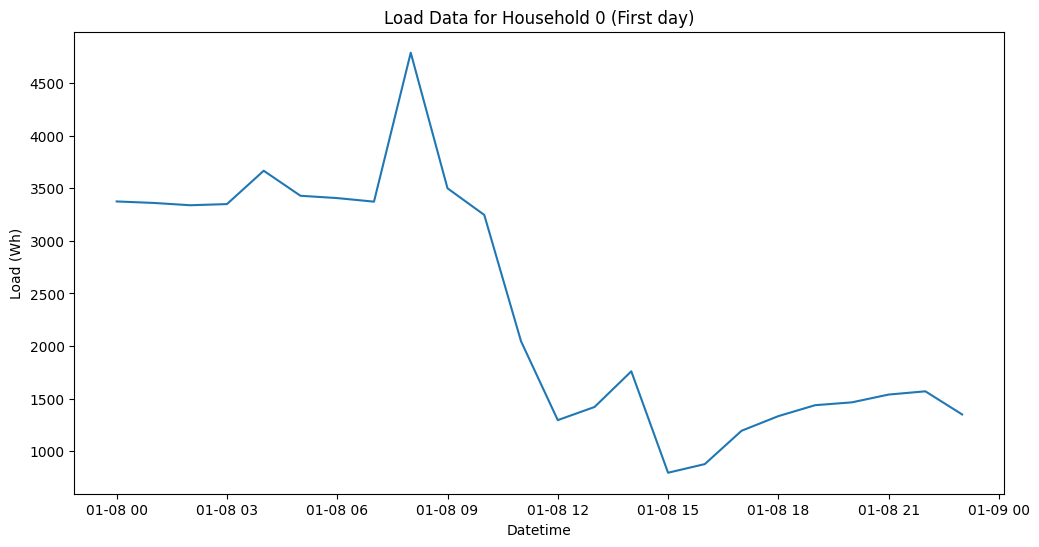

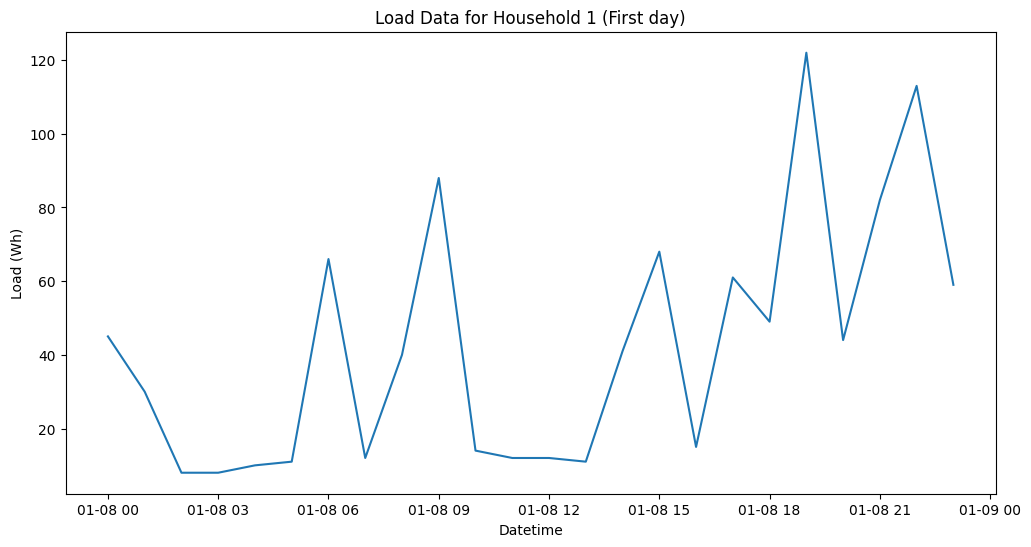

In [ ]:
import matplotlib.pyplot as plt
print(load_df_sorted[load_df_sorted['id'] == 0].describe())
plt.figure(figsize=(12, 6))
plt.plot(load_df_sorted['datetime'][0:24], load_df_sorted['value_Wh'][0:24])
plt.title('Load Data for Household 0 (First day)')
plt.xlabel('Datetime')
plt.ylabel('Load (Wh)')
plt.show()
plt.figure(figsize=(12, 6))
plt.plot(load_df_sorted[load_df_sorted['id'] == 1]['datetime'][0:24], load_df_sorted[load_df_sorted['id'] == 1]['value_Wh'][0:24])
plt.title('Load Data for Household 1 (First day)')
plt.xlabel('Datetime')
plt.ylabel('Load (Wh)')
plt.show()